In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"  # Limit OpenMP threads to 1
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

In [2]:
import sys, os
import feelpp.core as fppc
import feelpp.toolboxes.core as tb
from feelpp.toolboxes.cfpdes import *

# ─────────────── 1. Feel++ Environment ───────────────
sys.argv = ["feelpp_cfpdes_Heat1D_via2D"]
env = fppc.Environment(
    sys.argv,
    opts=tb.toolboxes_options("coefficient-form-pdes", "cfpdes"),
    config=fppc.localRepository("cfpdes-Heat1D-via2D")
)

# ─────────────── 2. Generate Geometry & Mesh ───────────────
def generateGeometry1D(filename, x0=0, x1=2, eps=0.01, hsize=0.01):
    geo = f"""SetFactory("OpenCASCADE");
h = {hsize};
Rectangle(1) = {{{x0}, {-eps}, 0, {x1-x0}, {eps}, 0}};
Characteristic Length{{ PointsOf{{ Surface{{1}}; }} }} = h;
Physical Curve("Gamma_D") = {{2,4}};
Physical Curve("Gamma_N") = {{1,3}};
Physical Surface("Omega") = {{1}};
"""
    with open(filename, "w") as f:
        f.write(geo)


def getMesh1D(filename, x0=-1, x1=1, eps=0.01, hsize=0.05, verbose=False):
    for ext in [".geo", ".msh"]:
        fn = os.path.splitext(filename)[0] + ext
        if os.path.exists(fn):
            os.remove(fn)
    if verbose:
        print(f"Generate geometry and mesh: {filename}, hsize={hsize}")
    generateGeometry1D(filename, x0, x1, eps, hsize)
    return fppc.load(fppc.mesh(dim=2, realdim=2), filename, hsize)

# ─────────────── 3. JSON Configuration  ───────────────
# Pure heat equation: ∂_t u - α Δ u = 0  ⇔  d=1, c=α, beta=(0,0), f=0
Heat1D_json = lambda order, alpha=1.0, name="u": {
    "Name": "Heat1D_Parametric",
    "Models": {
        "cfpdes-2d": {"equations": "AdvDiff"},
        "AdvDiff": {
            "setup": {
                "unknown": {"basis": f"Pch{order}", "name": name, "symbol": name},
                "coefficients": {
                    "d": "1.",
                    "c": f"{alpha}",
                    "f": "1."
                }
            }
        }
    },
    "Materials": {
        "Omega": {"markers": ["Omega"]}
    },
    "BoundaryConditions": {
        "AdvDiff": {
            "Dirichlet": {
                name: {
                    "markers": ["Gamma_D"],
                    "expr": "0"
                }
            },
            "Neumann": {
                name: {
                    "markers": ["Gamma_N"],
                    "expr": "0"
                }
            }
        }
    },
    "InitialConditions": {
        "AdvDiff": {
            name: {
                "Expression": {
                    "initial": {
                        "markers": ["Omega"],
                        "expr":
                            "exp(-10*(x)^2):x:y"
                    }
                }
            }
        }
    },
    "PostProcess": {
        "cfpdes-2d": {"Exports": {"fields": ["all"]}}
    }
}

# ─────────────── 4. CFG File ───────────────
Heat1D_cfg = lambda time_order=1, t0=0, T=0.03, dt=0.003: f"""
case.dimensions=2
[cfpdes]
pc-type=gamg
snes-monitor=1
reuse-prec=1
[cfpdes.AdvDiff.bdf]
order={time_order}
[ts]
time-initial={t0}
time-step={dt}
time-final={T}
restart.at-last-save=true
"""

# ─────────────── 5. Main Solver Function ───────────────
def SolveHeat1D(
    x0=-1, x1=1, eps=0.02,
    hsize=0.01, order=1, alpha=1.0,
    cfg_file="Heat1D.cfg", verbose=False
):
    # 1) Write cfg file
    cfg_str = Heat1D_cfg(time_order=1, t0=0., T=0.03, dt=0.003)
    with open(cfg_file, "w") as f:
        f.write(cfg_str)
    # 2) Set environment
    fppc.Environment.setConfigFile(cfg_file)
    # 3) Initialize cfpdes model
    model = cfpdes(dim=2, keyword="cfpdes-2d")
    # 4) Mesh
    mesh = getMesh1D("heat1d.geo", x0, x1, eps, hsize, verbose)
    model.setMesh(mesh)
    # 5) Model properties
    json = Heat1D_json(order=order, alpha=alpha, name="u")
    model.setModelProperties(json)
    # 6) Initialize algebraic factory, etc.
    model.init(buildModelAlgebraicFactory=True)
    model.printAndSaveInfo()
    # 7) Time stepping
    model.exportResults()
    model.startTimeStep()
    while not model.timeStepBase().isFinished():
        if model.worldComm().isMasterRank() and verbose:
            print(f"[t = {model.time()}]")
        model.solve()
        model.exportResults()
        model.updateTimeStep()

# ─────────────── 6. Example Execution ───────────────

SolveHeat1D(
    x0=-1, x1=1, eps=0.05,
    hsize=0.001, order=1, alpha=0.5,
    cfg_file="Heat1D.cfg",
    verbose=True
)

[ Starting Feel++ ] application feelpp_cfpdes_Heat1D_via2D version 0.1 date 2025-May-27
[feelpp] create Feel++ results directory: /home/u4/csmi/2024/he/FEMPIMM/MiniExamples/feelppdb/cfpdes-Heat1D-via2D/np_1

[feelpp] create Feel++ expressions directory: /home/u4/csmi/2024/he/FEMPIMM/MiniExamples/feelppdb/cfpdes-Heat1D-via2D/exprs

[feelpp] create Feel++ logs directory: /home/u4/csmi/2024/he/FEMPIMM/MiniExamples/feelppdb/cfpdes-Heat1D-via2D/np_1/logs

 . feelpp_cfpdes_Heat1D_via2D files are stored in /home/u4/csmi/2024/he/FEMPIMM/MiniExamples/feelppdb/cfpdes-Heat1D-via2D/np_1
 .. logfiles :/home/u4/csmi/2024/he/FEMPIMM/MiniExamples/feelppdb/cfpdes-Heat1D-via2D/np_1/logs
Reading /home/u4/csmi/2024/he/FEMPIMM/MiniExamples/feelppdb/cfpdes-Heat1D-via2D/np_1/Heat1D.cfg...
Generate geometry and mesh: heat1d.geo, hsize=0.001
[loadMesh] Loading mesh in format geo+msh: "/home/u4/csmi/2024/he/FEMPIMM/MiniExamples/feelppdb/cfpdes-Heat1D-via2D/np_1/heat1d.geo"
[loadMesh] Use default geo desc: /home

 | |
| | | |  name           : u_previous               | |                                                       | |
| | | |  prefix symbol  : AdvDiff                  | |                                                       | |
| | | +--------------------------------------------+ |                                                       | |
| | | +--------------------------------------------+ |                                                       | |
| | | | u_remove_trial                             | |                                                       | |
| | | +--------------------------------------------+ |                                                       | |
| | | |  base symbol    : u_rt                     | |                                                       | |
| | | |  function space : /FunctionSpace/object-0  | |                                                       | |
| | | |  name           : u_remove_trial           | |                                     

2025-05-27 05:39:03.653 (   1.220s) [    7F2ED28D7000]vtkXOpenGLRenderWindow.:1416  WARN| bad X server connection. DISPLAY=


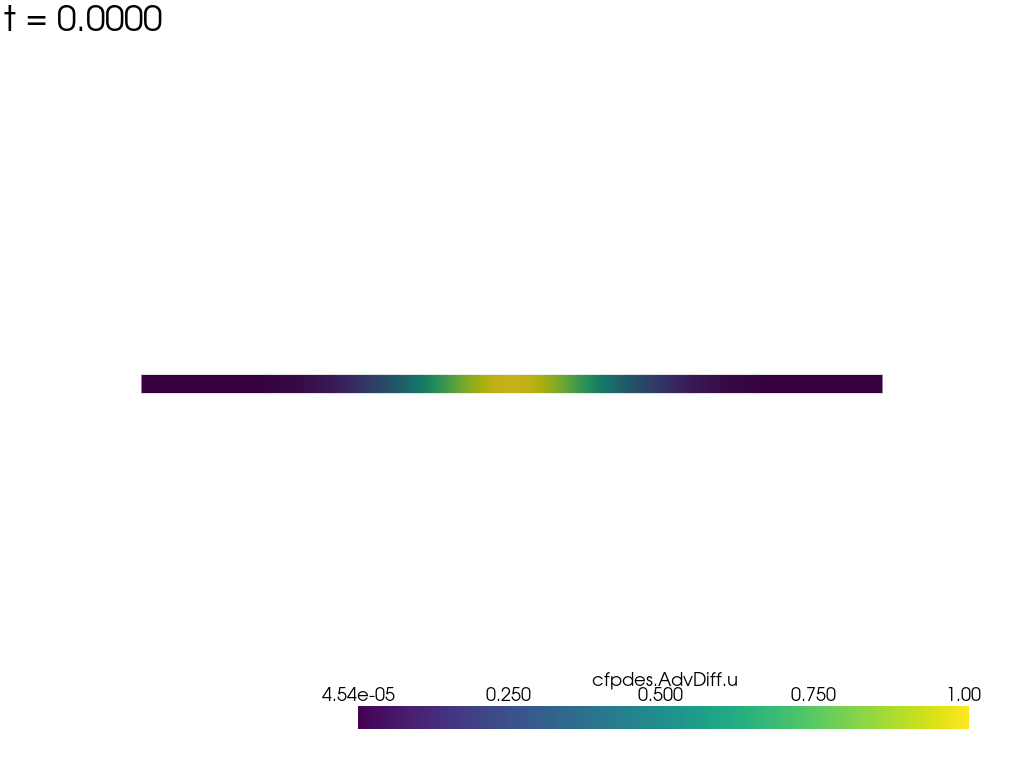

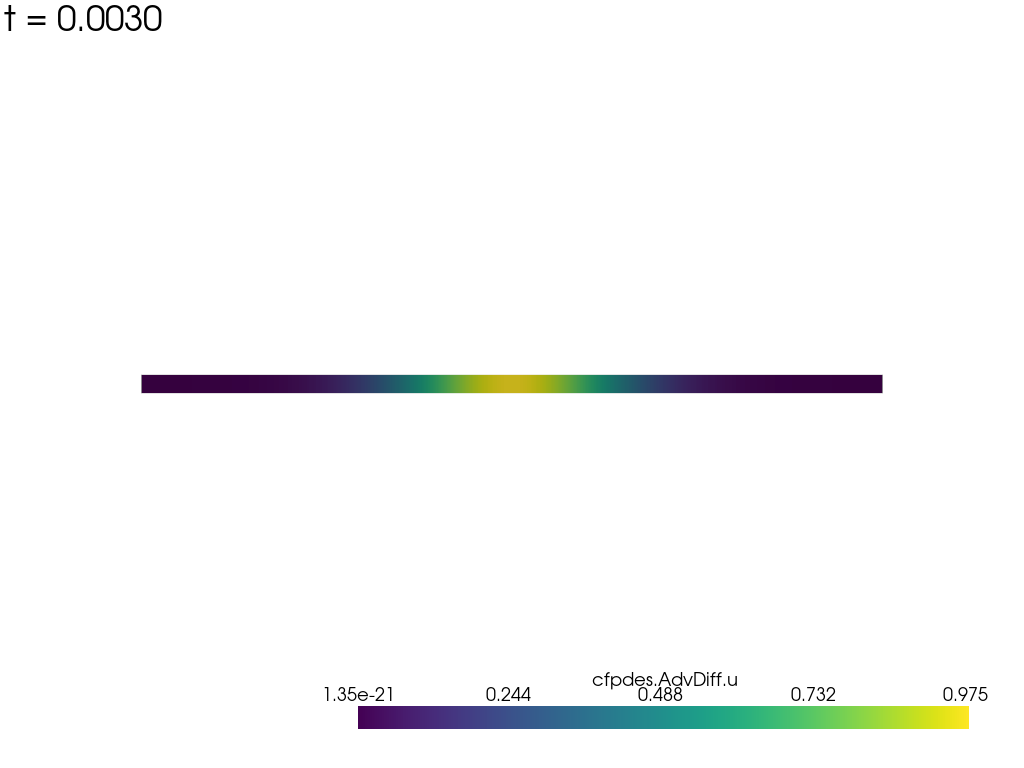

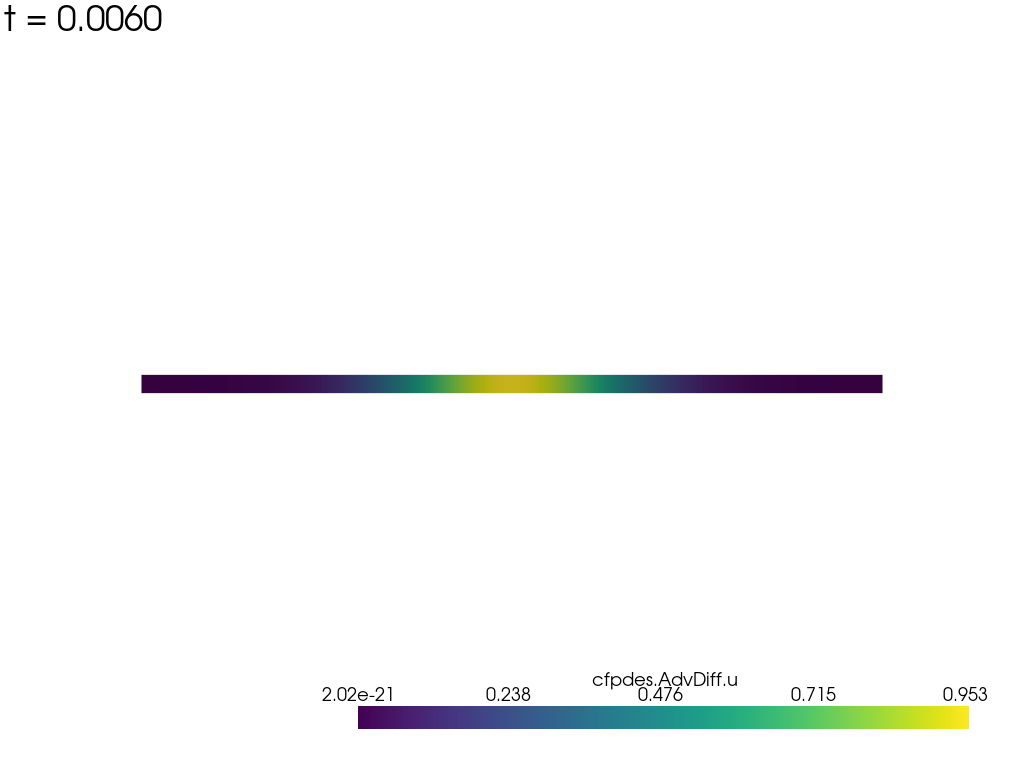

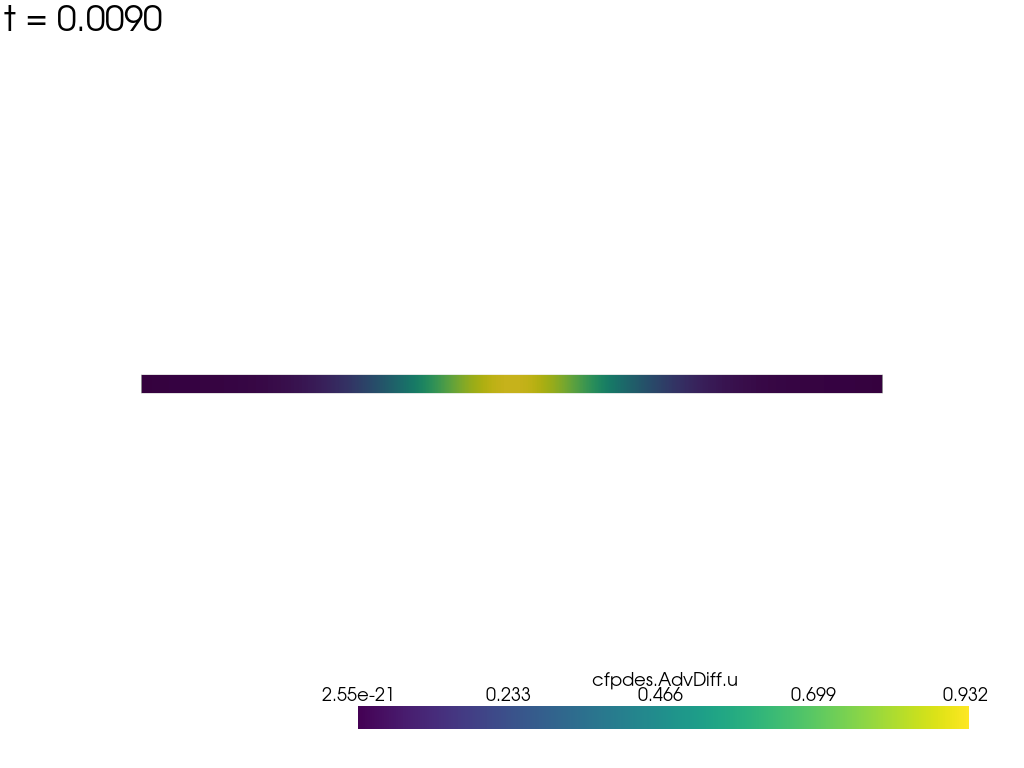

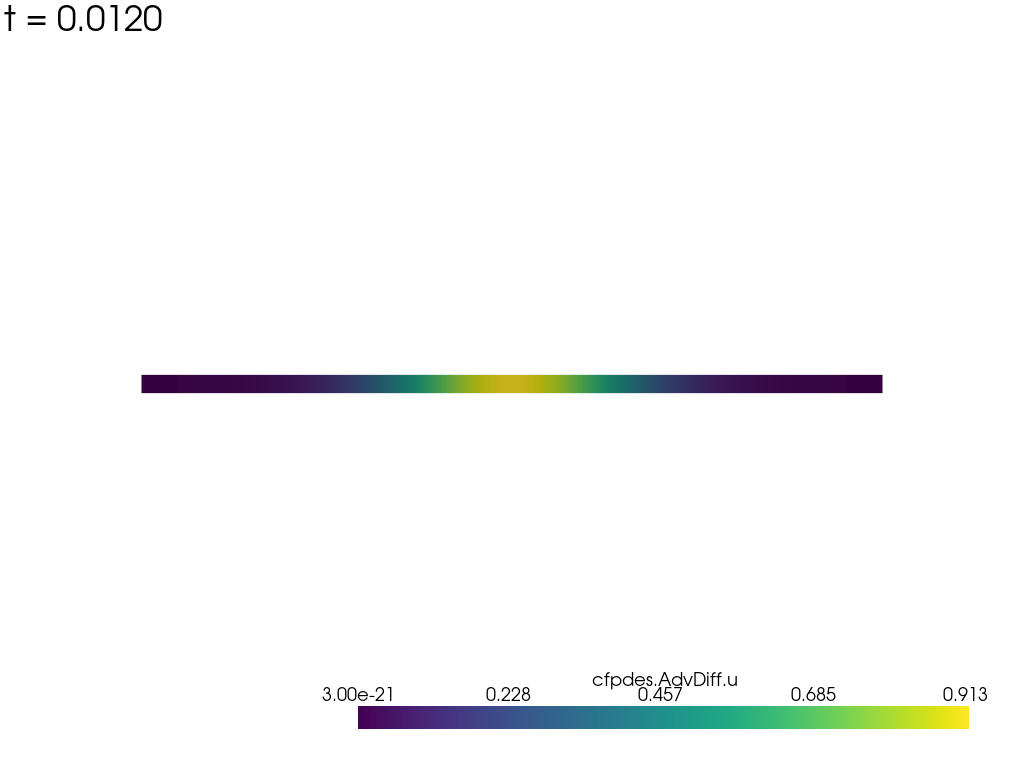

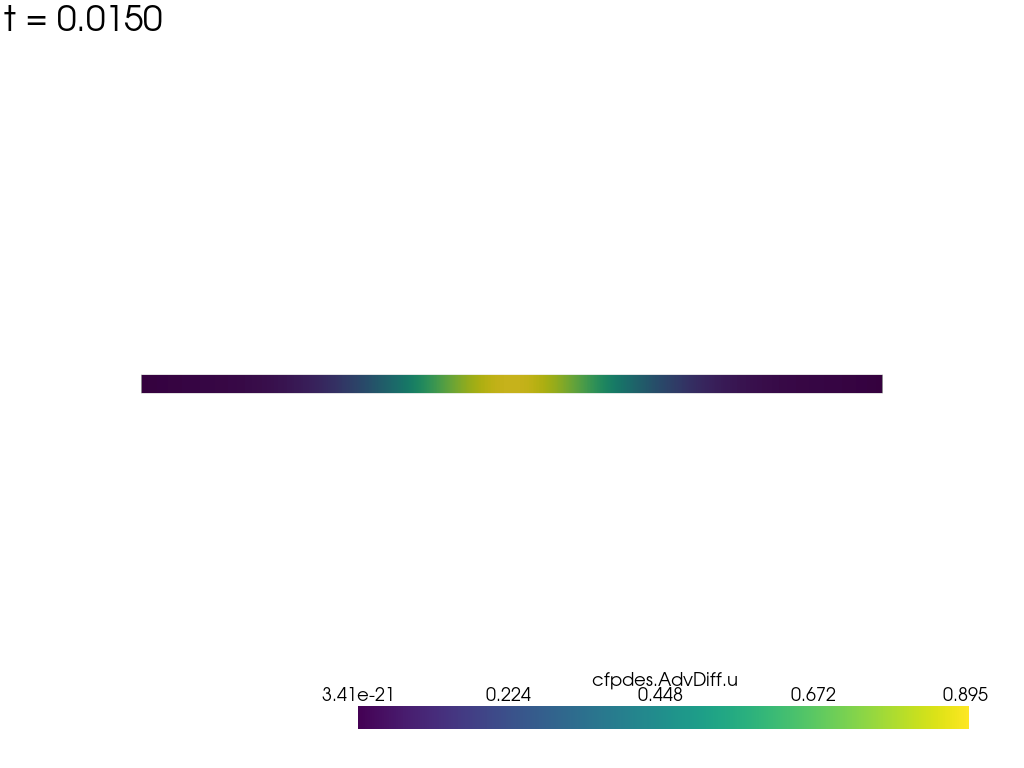

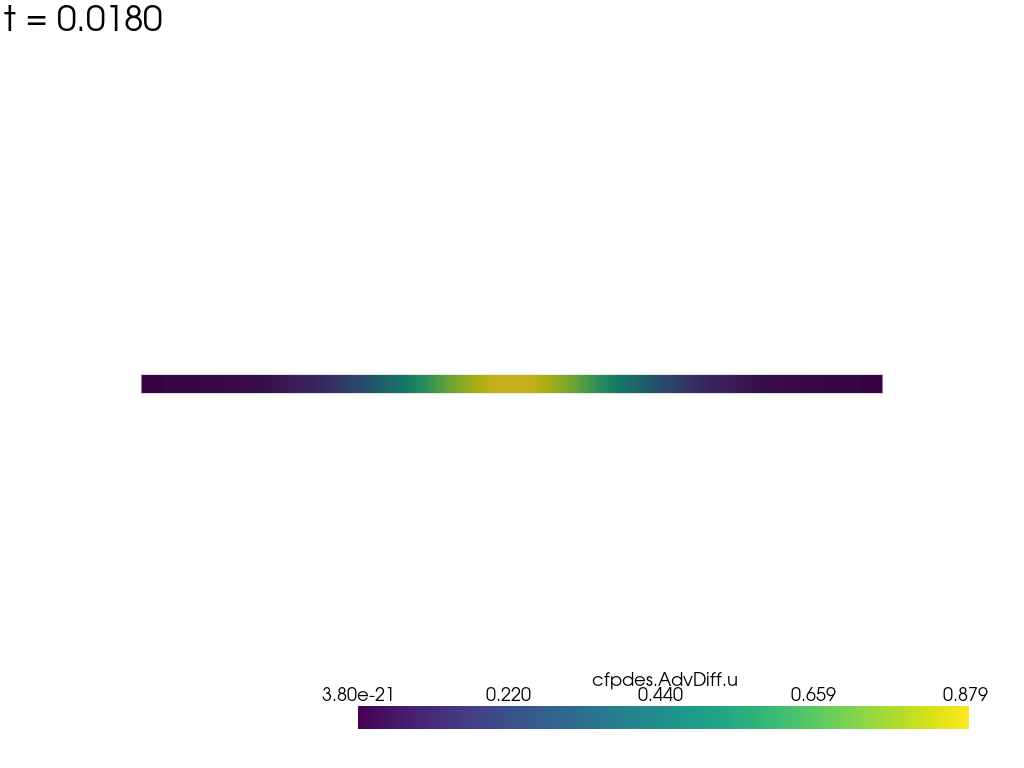

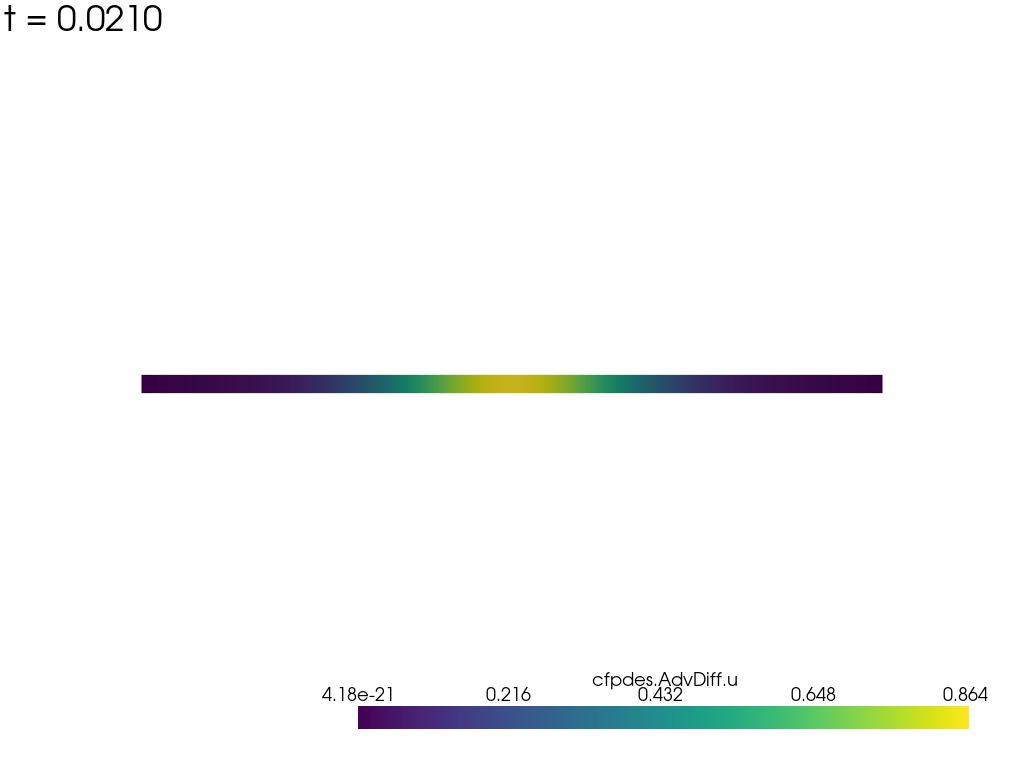

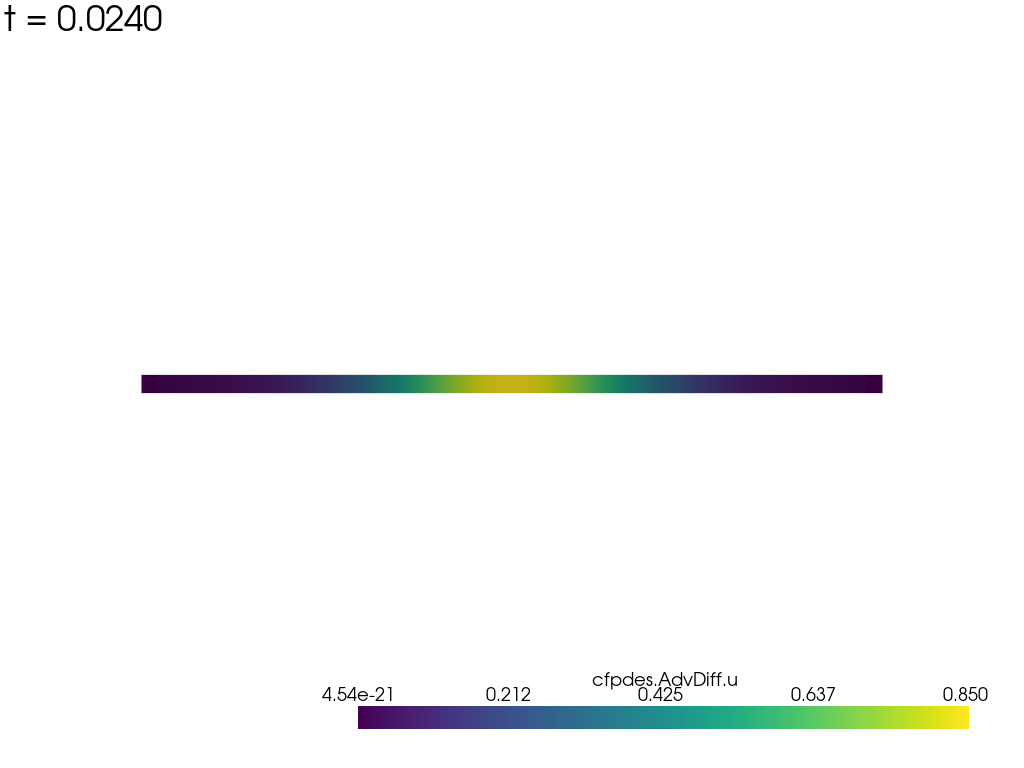

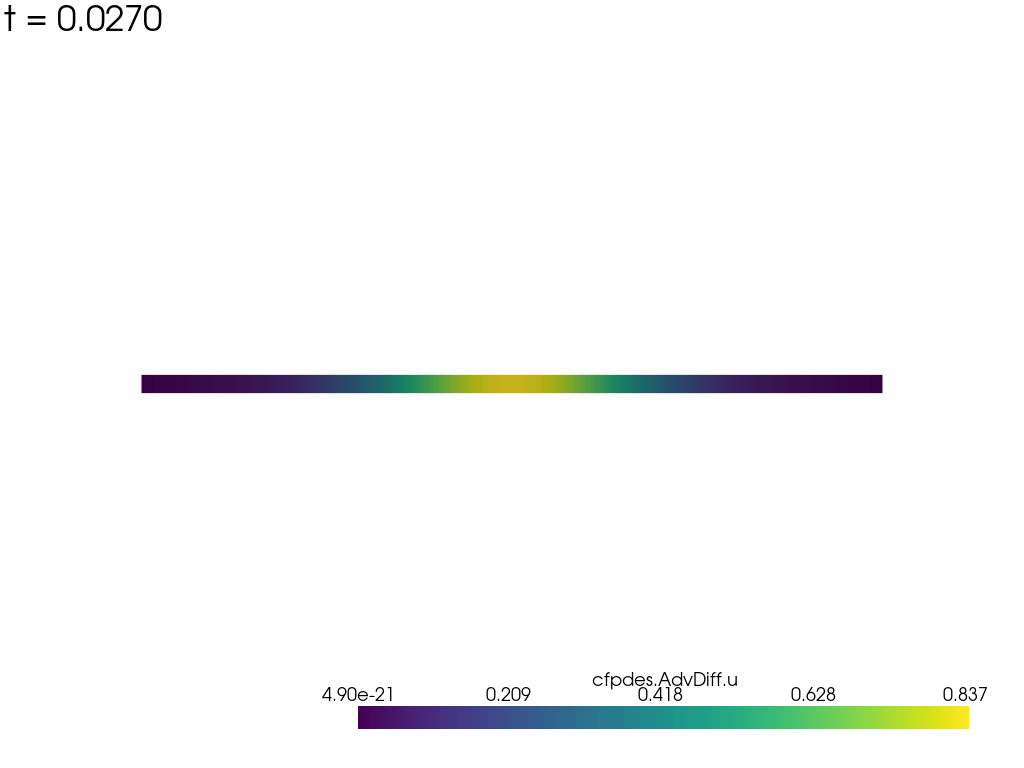

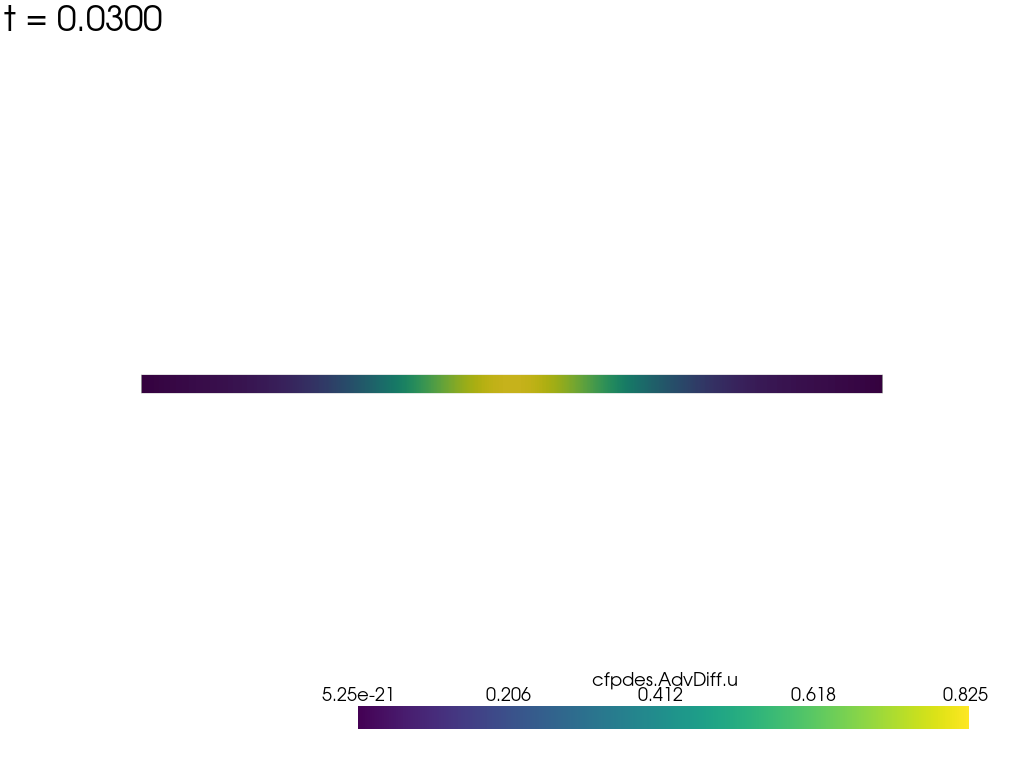

In [3]:
import pyvista as pv
import os

# Set static backend (avoid GUI errors)
pv.set_jupyter_backend('static')

# Path to .case file
case_path = os.path.abspath("cfpdes-2d.exports/Export.case")

# Create reader
reader = pv.get_reader(case_path)

# Extract time step list
time_values = reader.time_values
print(f"⏱️ Detected {len(time_values)} time frames: {time_values}")

# Display each frame
for i, t in enumerate(time_values):
    reader.set_active_time_value(t)
    mesh = reader.read()
    
    # If MultiBlock dataset, take the first block
    block = mesh[0] if isinstance(mesh, pv.MultiBlock) else mesh

    # Get scalar field names
    field_names = list(block.point_data.keys())
    if not field_names:
        print(f"⚠️ No scalar data in frame {i}")
        continue
    scalar_name = field_names[0]

    # Visualization
    p = pv.Plotter()
    p.add_mesh(block, scalars=scalar_name, cmap="viridis", show_edges=False)
    p.add_text(f"t = {t:.4f}", font_size=14)
    p.view_xy()
    p.show()


⏱️ Detected 11 time frames: [0.0, 0.003, 0.006, 0.009, 0.012, 0.015, 0.018, 0.021, 0.024, 0.027, 0.03]
🎯 Selected time frame indices: [ 0  2  5  7 10]


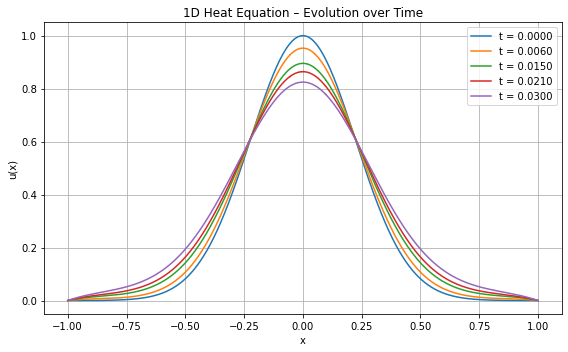

In [4]:
import pyvista as pv
import matplotlib.pyplot as plt
import numpy as np
import os
from collections import defaultdict

# Read .case file
case_path = os.path.abspath("cfpdes-2d.exports/Export.case")
reader = pv.get_reader(case_path)
time_values = reader.time_values
print(f"⏱️ Detected {len(time_values)} time frames: {time_values}")

# ─────────────── Select 5 key time steps (evenly spaced) ───────────────
num_frames = len(time_values)
selected_indices = np.linspace(0, num_frames - 1, 5, dtype=int)
print(f"🎯 Selected time frame indices: {selected_indices}")

# ─────────────── Start plotting ───────────────
plt.figure(figsize=(8, 5))

for idx in selected_indices:
    t = time_values[idx]
    reader.set_active_time_value(t)
    mesh = reader.read()
    block = mesh[0] if isinstance(mesh, pv.MultiBlock) else mesh

    field_names = list(block.point_data.keys())
    if not field_names:
        print(f"⚠️ No scalar data in frame {idx}")
        continue
    u_name = field_names[0]
    u_vals = block.point_data[u_name]
    coords = block.points
    x_vals = coords[:, 0]
    y_vals = coords[:, 1]

    # Group by x coordinate, average values in y direction
    x_bins = defaultdict(list)
    for xi, yi, ui in zip(x_vals, y_vals, u_vals):
        x_bins[xi].append(ui)

    x_unique = sorted(x_bins.keys())
    u_avg = [np.mean(x_bins[xi]) for xi in x_unique]

    # Plot the curve for the current time frame
    plt.plot(x_unique, u_avg, label=f"t = {t:.4f}")

# Beautify the plot
plt.xlabel("x")
plt.ylabel("u(x)")
plt.title("1D Heat Equation – Evolution over Time")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("heat1d_evolution.png")  # Optional save
plt.show()
